# **EDA, linear regression. Взаимосвязь экономических факторов и рождаемости**

Социально-экономические и политические изменения, происходившие в России на протяжении XX-XXI века, коснулись и демографических процессов. Прежде всего, изменилось репродуктивное поведение населения, которое стало мощным фактором изменения уровня рождаемости. В результате, сегодня уровень рождаемости находится ниже уровня простого воспроизводства населения, что ведет к сокращению населения. Возникает вопрос, как увеличить рождаемость?

Основными факторами, влияющими на рождаемость, являются, с одной стороны, сложившаяся демографическая структура (половой, возрастной состав населения и др.), а с другой-репродуктивное поведение. При этом, если демографическая структура-это условие, которое в настоящий момент нельзя изменить, то репродуктивное поведение изменяется под действием различных факторов:  климатических, социальных, экономических, медицинских и пр.
Посмотрим, есть ли связь между экономическими факторами и рождаемостью в России. Последнее может означать, что проводя грамотную экономическую политику можно увеличить рождаемость.

In [47]:
#!pip install ydata-profiling -U

In [2]:
# Ипортируем библиотеки
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

/tmp/ipykernel_84054/1419903334.py:11: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [3]:
# Изменим значение максимального количества отображаемых строк и столбцов
pd.options.display.max_columns = 20
pd.options.display.max_rows = 100
# Поменяем формат вывода чисел: разделим разряды запятой и будем выводить два знака после точки
pd.options.display.float_format = '{:,.2f}'.format

In [4]:
# Зададим параметры, которые будут использоваться в расчетах ниже
random_state=12345

## **Сбор данных и формулирование гипотез**

In [5]:
%%time
# Загрузим датасет с GitHub
url = "https://raw.githubusercontent.com/eilicheva-art/datasets/refs/heads/main/russian_regions_stats_2024.csv"
df = pd.read_csv(url)
# Выведем первые пять строк
df.head()

CPU times: user 18.8 ms, sys: 56 µs, total: 18.9 ms
Wall time: 134 ms


,Регион,ФО,x1,x2,x3,x4,x5,y
0,Белгородская область,ЦФО,56798,65.40,4.40,3.47,36.98,6.10
1,Брянская область,ЦФО,48502,69.80,9.10,3.86,33.71,6.50
2,Владимирская область,ЦФО,46302,77.59,7.40,2.31,33.49,6.20
3,Воронежская область,ЦФО,53449,68.50,5.40,3.97,35.58,6.90
4,Ивановская область,ЦФО,47881,82.20,8.00,2.69,32.49,6.90


In [6]:
%%time
# Выведем количество строк в датасете
print("Количество наблюдений:", df.shape[0])

Количество наблюдений: 85
CPU times: user 126 µs, sys: 0 ns, total: 126 µs
Wall time: 934 µs


В датасете представлены данные по 85 субъектам РФ за 2024 год:
- `Регион` - регион РФ;
- `ФО` - федеральный округ;
- `х1` - среднедушевые денежные доходы (в рублях);
- `x2` - доля городского населения в общей численности населения (%);
- `х3` - численность населения с денежными доходами ниже величины прожиточного минимума (в % от общей численности населения  субъекта);
- `х4` - уровень безработицы (%);
- `x5` - общая площадь жилых помещений, приходящаяся в среднем на одного жителя (кв. м.);
- `y` - общий коэффициент рождаемости (число родившихся на 1000 человек населения в промилле (0,1 процента)).

**Формулировка рабочих гипотез**: **H1** коэффициент рождаемости `y` имеет нормальный закон распределения; **H2** отсутствует линейная корреляционная зависимость между уровнем рождаемости и среднедушевыми доходами населения; **H3** отсутствует линейная корреляционная зависимость между удельным весом городского населения в общей численности населения и коэффициентом рождаемости; **H4** отсутствует линейная корреляционная зависимость между численностью населения с денежными доходами ниже величины прожиточного минимума и коэффициентом рождаемости; **H5** отсутствует линейная корреляционная зависимость между уровнем безработицы и коэффициентом рождаемости; **H6** отсутствует линейная корреляционная зависимость между общей площадью жилых помещений, приходящаяся в среднем на одного жителя и коэффициентом рождаемости.

## **Предобработка данных (EDA)**

### Автоматический EDA отчет

In [7]:
%%time
# Сформируем автоматический EDA - отчет
profile = ProfileReport(df, title="dataset Report", explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 49.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 11.7 s, sys: 382 ms, total: 12.1 s
Wall time: 20.2 s


### **Типы данных и пропуски**

In [8]:
%%time
# Получим общую информацию о данных в таблице df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регион  85 non-null     object 
 1   ФО      85 non-null     object 
 2   x1      85 non-null     int64  
 3   x2      85 non-null     float64
 4   x3      85 non-null     float64
 5   x4      85 non-null     float64
 6   x5      85 non-null     float64
 7   y       85 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 5.4+ KB
CPU times: user 8.73 ms, sys: 0 ns, total: 8.73 ms
Wall time: 38.4 ms


В датасете типы данных  признаков определены корректно: `Регион` и `ФО` имеют тип object, `х1` - int, `x2`, `х3`, `х4`, `x5`, `y` тип float. Количество значений во всех столбцах равно 85. Значит, в данных нет пропусков.

### **Дубликаты**

In [9]:
%%time
# Подсчёт дубликатов
df.duplicated().sum()

CPU times: user 1.76 ms, sys: 0 ns, total: 1.76 ms
Wall time: 9.68 ms


np.int64(0)

In [10]:
%%time
# Проверка на неявные дубликаты и ошибки в названиях
# df['ФО'].sort_values().unique()
# df['Регион'].sort_values().unique()
len(df['Регион'].sort_values().unique())

CPU times: user 819 µs, sys: 67 µs, total: 886 µs
Wall time: 6.39 ms


85

В датасете нет дубликатов.

### **Наименования столбцов**

In [11]:
%%time
# Переименование столбцов
df = df.rename(columns={'Регион':'region', 'ФО':'area'})

CPU times: user 1.41 ms, sys: 35 µs, total: 1.44 ms
Wall time: 1.37 ms


In [12]:
%%time
# Проверка результатов переименования - перечень названий столбцов
df.columns

CPU times: user 14 µs, sys: 1e+03 ns, total: 15 µs
Wall time: 19.3 µs


Index(['region', 'area', 'x1', 'x2', 'x3', 'x4', 'x5', 'y'], dtype='object')

### **Описательные статистики**

In [13]:
%%time
# Посмотрим на числовые характеристики количественнных признаков: количество, среднее, стандартное отклонение,
# минимальное значение, 25-й перцентиль, медиана, 75-й перцентиль и максимальное значение
df.describe()

CPU times: user 19.9 ms, sys: 0 ns, total: 19.9 ms
Wall time: 60.8 ms


,x1,x2,x3,x4,x5,y
count,85.00,85.00,85.00,85.00,85.00,85.00
mean,"58,141.85",71.19,8.96,4.25,29.80,8.42
std,"27,515.64",12.73,3.58,3.38,4.73,2.33
min,"27,311.00",30.40,3.40,1.32,15.86,5.50
25%,"44,730.00",64.59,6.70,2.61,27.00,6.90
50%,"50,738.00",71.50,8.40,3.40,30.34,7.80
75%,"61,278.00",78.40,10.20,4.35,33.17,8.90
max,"187,687.00",100.00,25.30,26.72,38.85,20.00


Количественные признаки `x2`, `х3`, `х4`, `x5`, `y` имеют примерно один порядок, в то время как `x1` - сильно отличается по масштабцу от остальных признаков.

In [14]:
%%time
# Характеристики для категориальных столбцов
df.describe(include='object')

CPU times: user 5.8 ms, sys: 0 ns, total: 5.8 ms
Wall time: 6.29 ms


,region,area
count,85,85
unique,85,8
top,Белгородская область,ЦФО
freq,1,18


Переведем `x1` в тыс. рублей.

In [15]:
df['x1'] = df['x1']/1000

### **Выбросы и изучение распределений**

In [16]:
# Определим список признаков
features = df.columns[2:]
# Определим словарь признаков
features_dict = {'x1':'Среднедушевые денежные доходы (в тыс. руб.)', 'x2':'Доля городского населения в общей численности населения (%)', \
                 'x3':'Численность населения с денежными доходами ниже величины прожиточного минимума (в % от общей численности населения субъекта)', \
                 'x4':'Уровень безработицы (%)', 'x5':'Общая площадь жилых помещений, приходящаяся в среднем на одного жителя (кв. м.)', \
                 'y':'Общий коэффициент рождаемости (число родившихся на 1000 человек населения в промилле (0,1 процента))'}

Строим графики для изучения распредения и выбросов по x1 - Среднедушевые денежные доходы (в тыс. руб.)


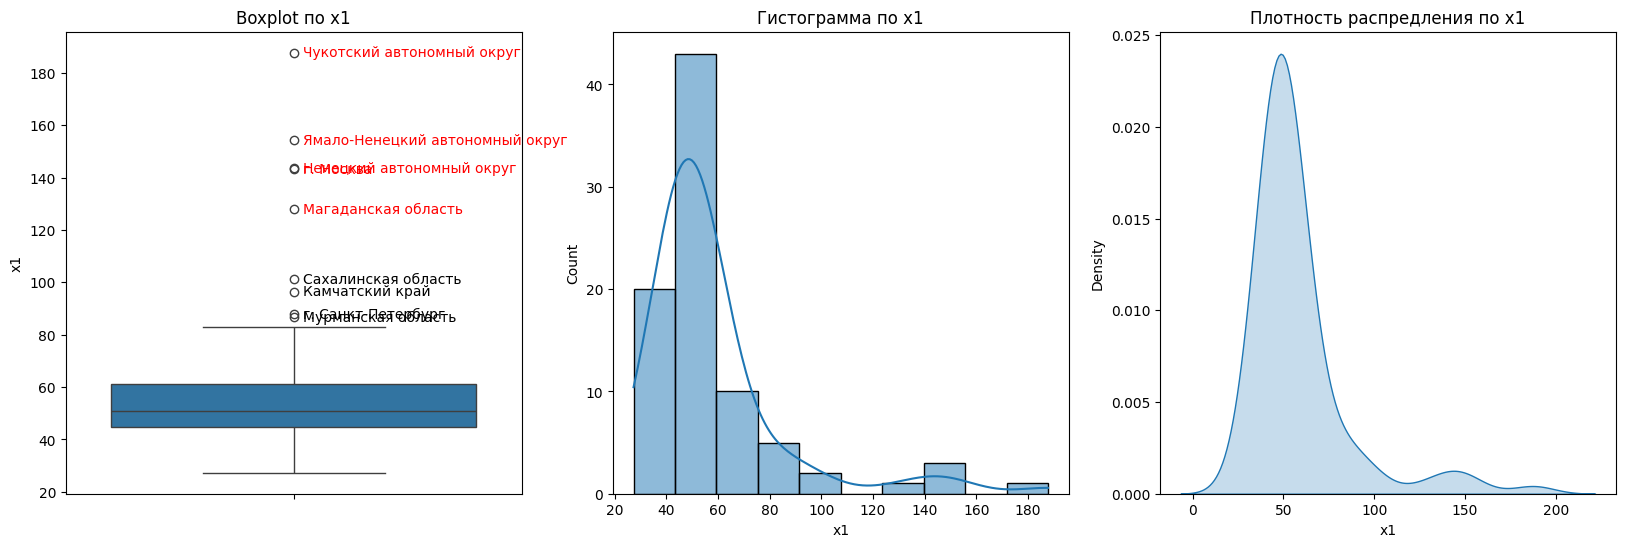

Строим графики для изучения распредения и выбросов по x2 - Доля городского населения в общей численности населения (%)


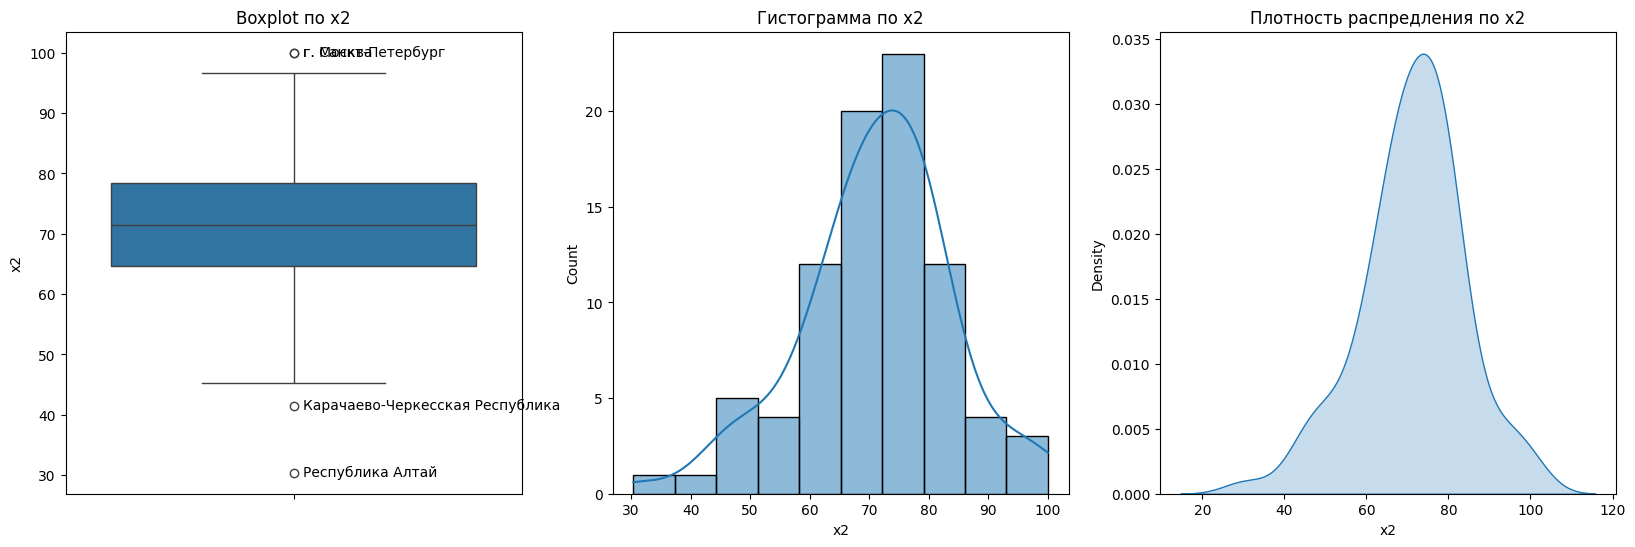

Строим графики для изучения распредения и выбросов по x3 - Численность населения с денежными доходами ниже величины прожиточного минимума (в % от общей численности населения субъекта)


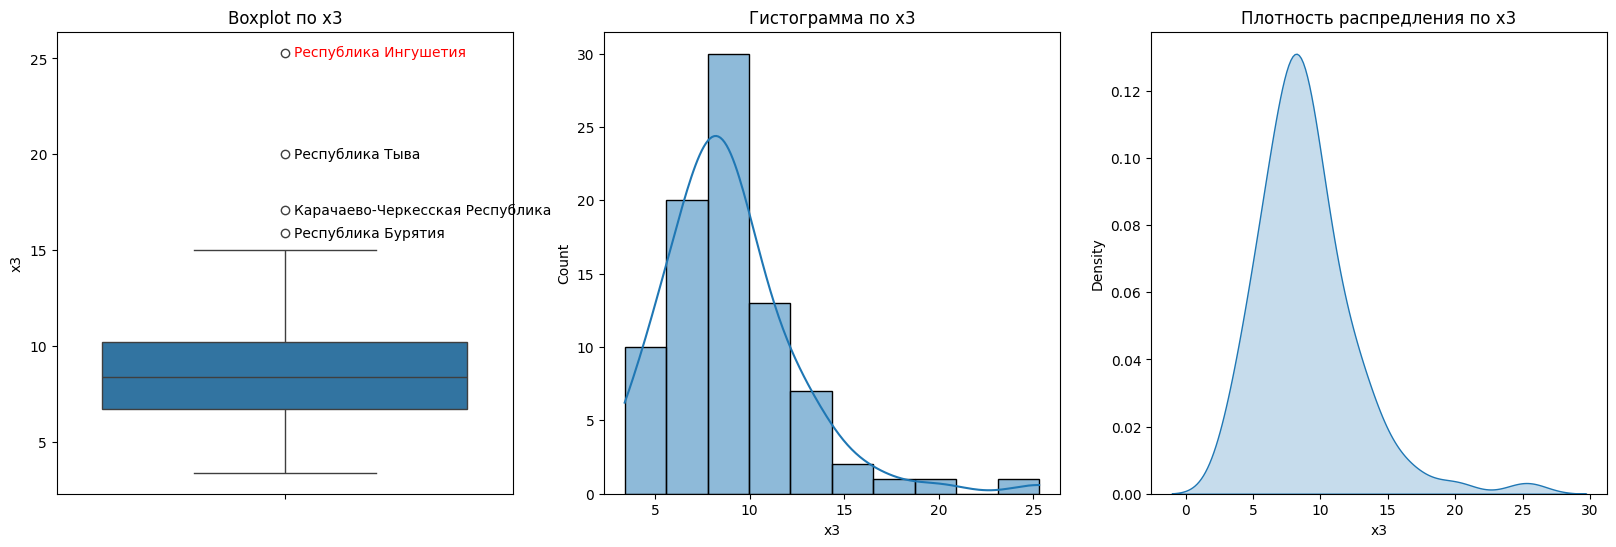

Строим графики для изучения распредения и выбросов по x4 - Уровень безработицы (%)


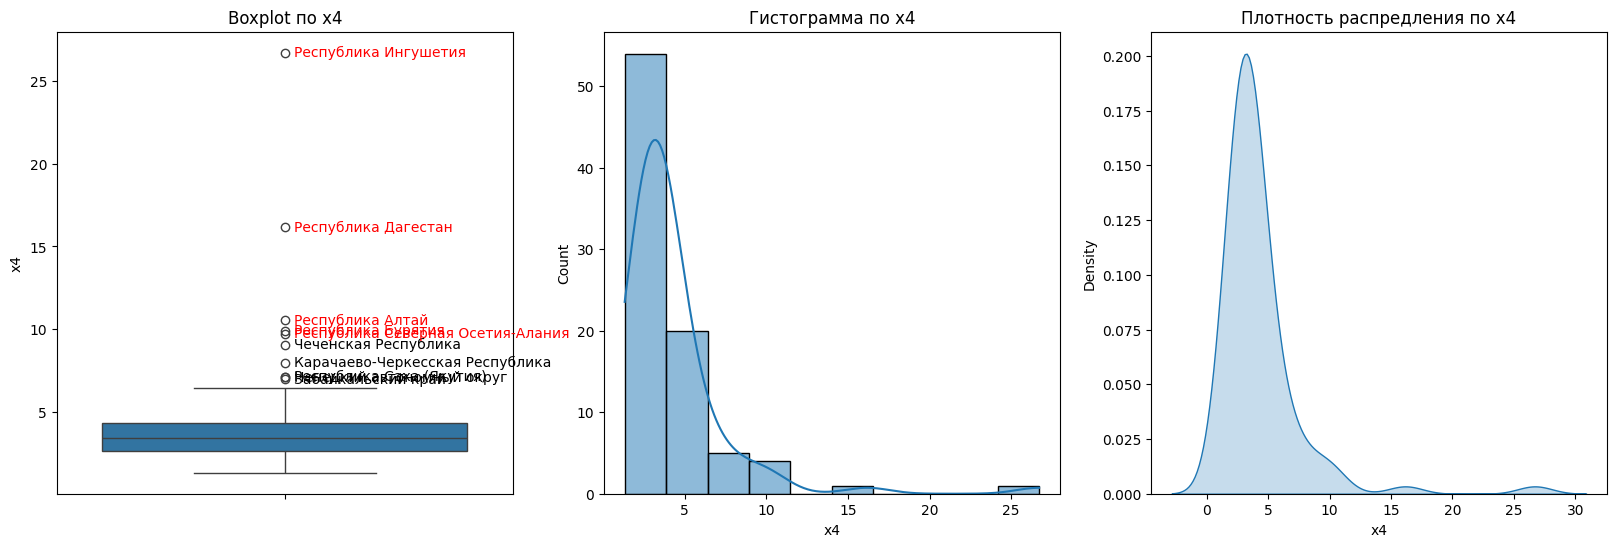

Строим графики для изучения распредения и выбросов по x5 - Общая площадь жилых помещений, приходящаяся в среднем на одного жителя (кв. м.)


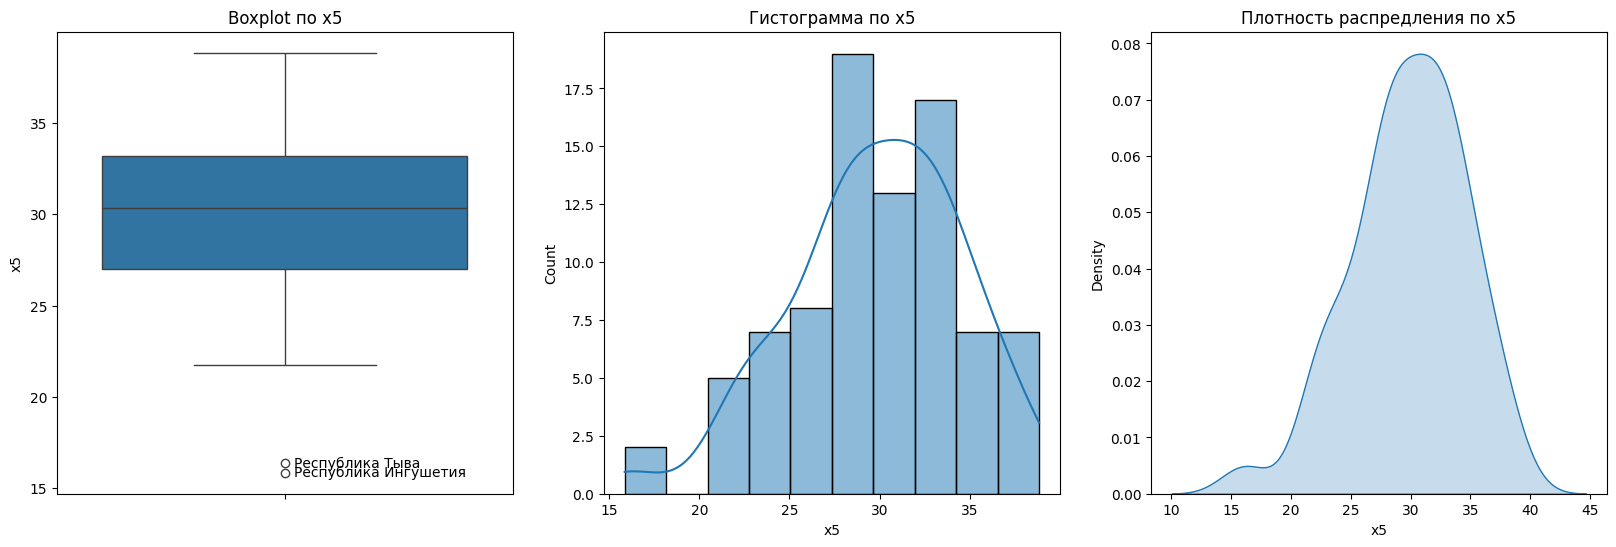

Строим графики для изучения распредения и выбросов по y - Общий коэффициент рождаемости (число родившихся на 1000 человек населения в промилле (0,1 процента))


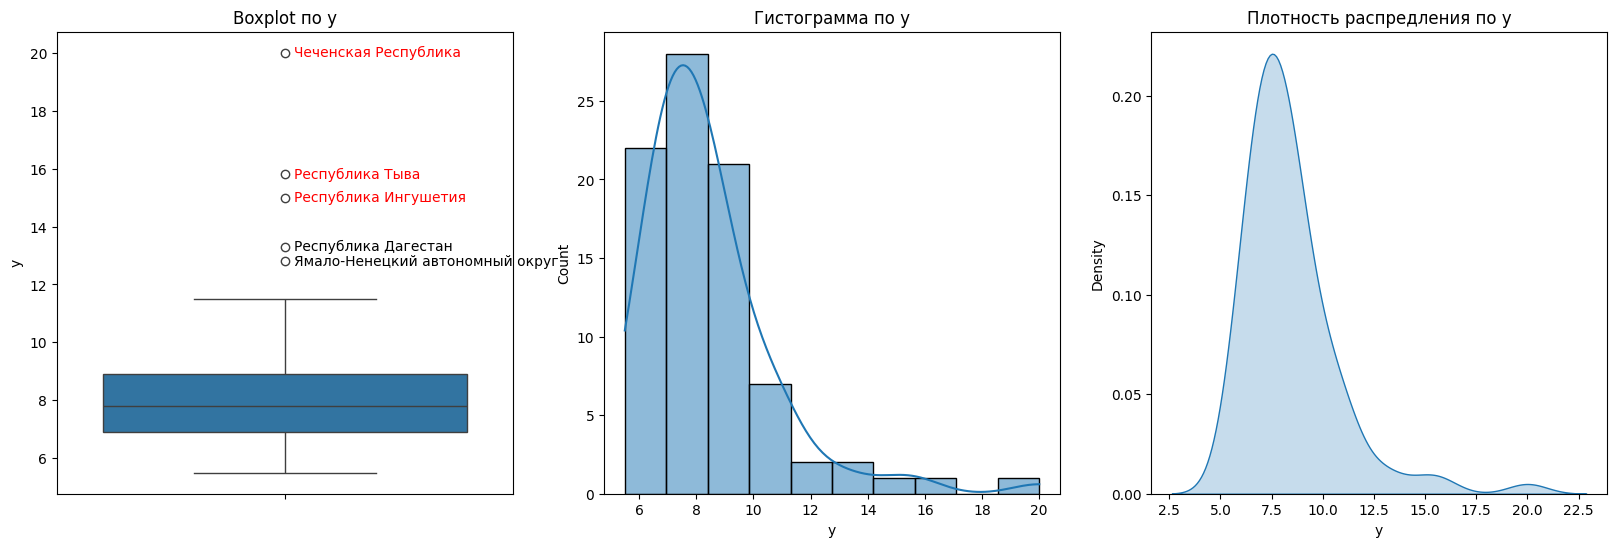

CPU times: user 5.57 s, sys: 88.5 ms, total: 5.65 s
Wall time: 10.5 s


In [17]:
%%time
# Строим графики для изучения распредения и выбросов по каждому признаку
for feature in features:
  print(f'Строим графики для изучения распредения и выбросов по {feature} - {features_dict[f'{feature}']}')
  plt.figure(figsize=(20, 6))

  # Визуализируем boxplot, выделим умеренный выбросы (в пределах диапазона от 1.5 до 3-х размахов) и экстремальные выбросы (вне диапазона 3-х размахов)
  plt.subplot(1,3,1)
  ax = sns.boxplot(data=df, y=f'{feature}')
  # Вычисляем границы выбросов
  Q1 = df[f'{feature}'].quantile(0.25)
  Q3 = df[f'{feature}'].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  lower_bound_critical = Q1 - 3 * IQR
  upper_bound_critical = Q3 + 3 * IQR
  # Находим выбросы
  outliers = df[((df[f'{feature}'] < lower_bound) & (df[f'{feature}'] >= lower_bound_critical) )|((df[f'{feature}'] > upper_bound) & (df[f'{feature}'] <= upper_bound_critical))]
  critical_outliers = df[(df[f'{feature}'] < lower_bound_critical)|(df[f'{feature}'] > upper_bound_critical)]
  # Подписываем точки
  for index, value in outliers.iterrows():
      # value[f'{feature}'] - значение, region - индекс строки
      ax.text(0.02, value[f'{feature}'], value['region'],
              horizontalalignment='left',
              verticalalignment='center',
              fontsize=10, color='black')
  for index, value in critical_outliers.iterrows():
      # value['x1'] - значение, region - индекс строки
      ax.text(0.02, value[f'{feature}'], value['region'],
              horizontalalignment='left',
              verticalalignment='center',
              fontsize=10, color='red')
  plt.title(f'Boxplot по {feature}')


  # Визуализируем гистограмму распределения признака и кривую плотности распределения
  plt.subplot(1,3,2)
  sns.histplot(data = df, x = f'{feature}', bins = 10, kde = True);
  plt.title(f'Гистограмма по {feature}')

  # Визуализируем кривую плотности распределения
  plt.subplot(1,3,3)
  sns.kdeplot(data=df, x=f'{feature}', fill=True)
  plt.title(f'Плотность распредления по {feature}')
  plt.show();

**Среднедушевые денежные доходы (x1)**

Построенная ящичковая диаграмма сообщает о наличии выбросов. Наблюдаемых значений, лежащих вне диапазона 3-х размахов-пять, они называются экстремальными выбросами, или далекими значениями, и обозначаются красными кружками, а наблюдений со значениями в пределах диапазона от 1.5 до 3-х размахов-четыре, они называются умеренными выбросами, или отклоняющимися значениями и обозначаются черными кружками (°).

**Общий коэффициент рождаемости (число родившихся на 1000 человек населения в промилле (0,1 процента)) (y)**

Построенная ящичковая диаграмма сообщает о наличии выбросов. Наблюдаемых значений, лежащих вне диапазона 3-х размахов-три (Чеченская республика, Республика Тыва, Республика Ингушетия), а наблюдений со значениями в пределах диапазона от 1.5 до 3-х размахов-два (Республика Дагестан, Ямало-Ненецкий автономный округ).

### **Корреляционный анализ**

Визуализируем признаки попарно (на исходном датасете без удаления выбросов)
CPU times: user 3.43 s, sys: 11.9 ms, total: 3.44 s
Wall time: 3.27 s


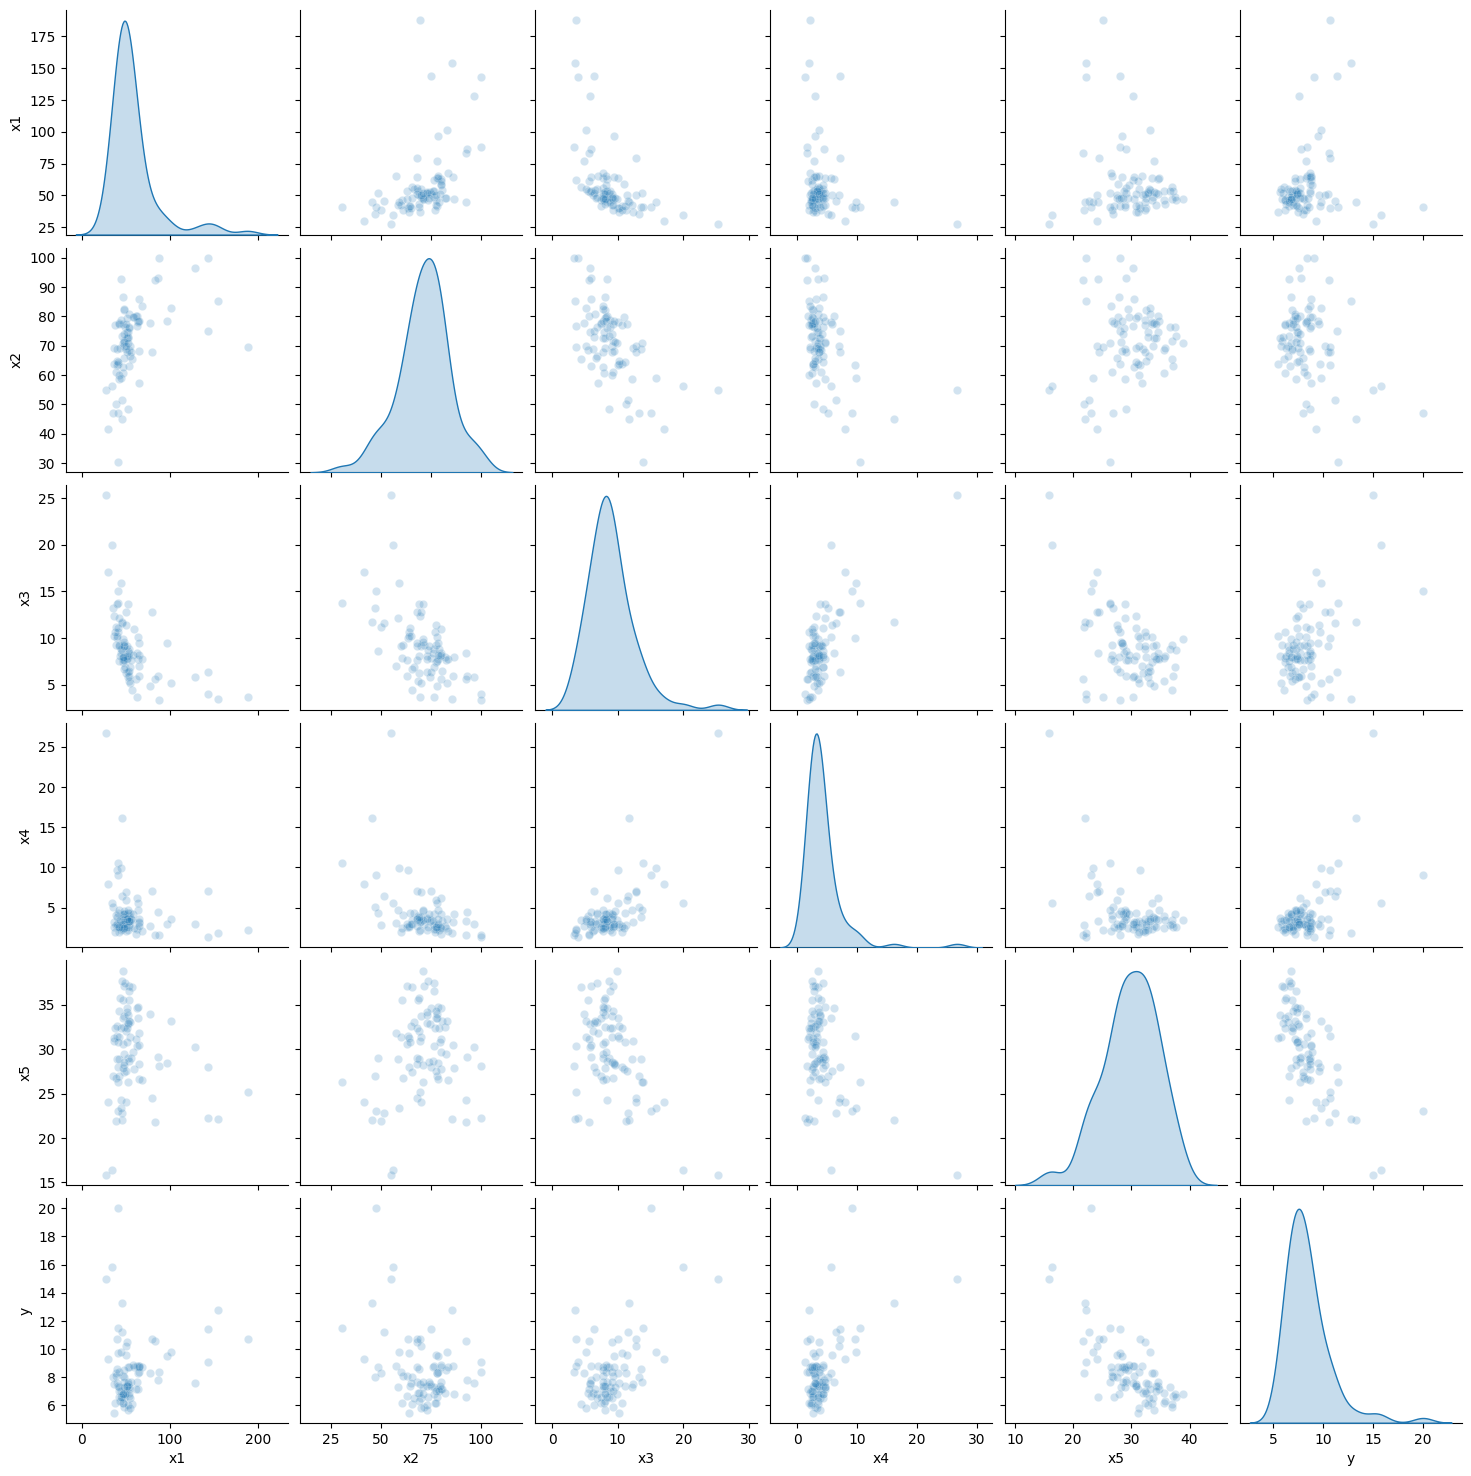

In [18]:
%%time
# Визуализируем признаки попарно
print('Визуализируем признаки попарно (на исходном датасете без удаления выбросов)')
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.2})

На значение коэффициента корреляции оказывают влияния выбросы, поэтому рассчитаем коэффициенты корреляции между `x1`-`x5` и `y` на исходном датасете, а таккже с удалением умеренный и экстремальных выбросов.

Строим графики scatterplot и рассчитываем коэффициенты корреляции по x1 - Среднедушевые денежные доходы (в тыс. руб.)


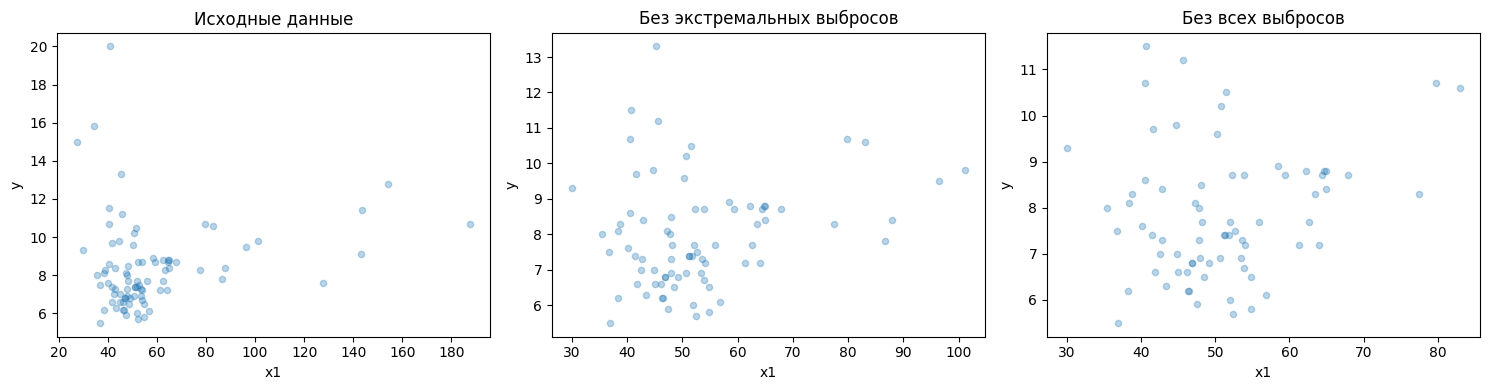

Корреляция для исходных данных: 0.17108589933239027
p_value 0.11745489892261936
Корреляция без экстремальных: 0.2219416757769847
p_value 0.05238645013336328
Корреляция без всех: 0.20648211946088427
p_value 0.08182362458826054
Строим графики scatterplot и рассчитываем коэффициенты корреляции по x2 - Доля городского населения в общей численности населения (%)


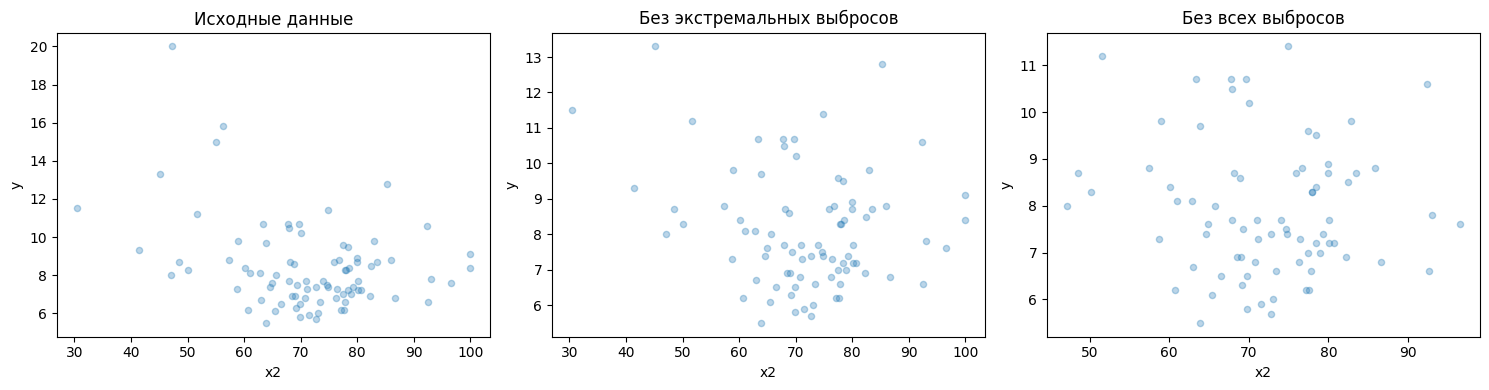

Корреляция для исходных данных: -0.3310206504413342
p_value 0.0019720622341397936
Корреляция без экстремальных: -0.190118130980353
p_value 0.08711720805587184
Корреляция без всех: -0.08638470494806365
p_value 0.45809219497018133
Строим графики scatterplot и рассчитываем коэффициенты корреляции по x3 - Численность населения с денежными доходами ниже величины прожиточного минимума (в % от общей численности населения субъекта)


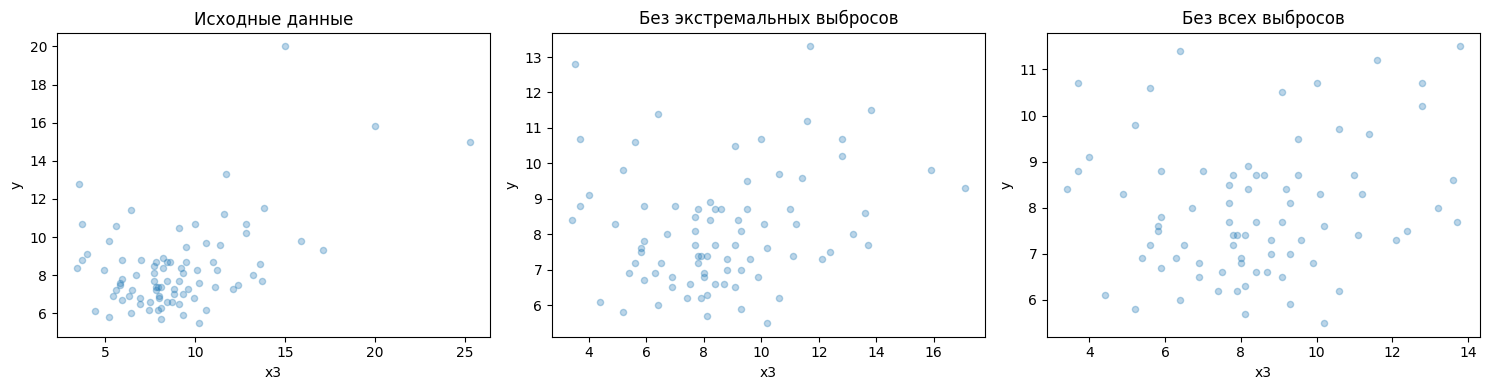

Корреляция для исходных данных: 0.47597011023965147
p_value 4.1448819419474414e-06
Корреляция без экстремальных: 0.17353255314287447
p_value 0.11896452342873025
Корреляция без всех: 0.16995874103959027
p_value 0.13684398115915172
Строим графики scatterplot и рассчитываем коэффициенты корреляции по x4 - Уровень безработицы (%)


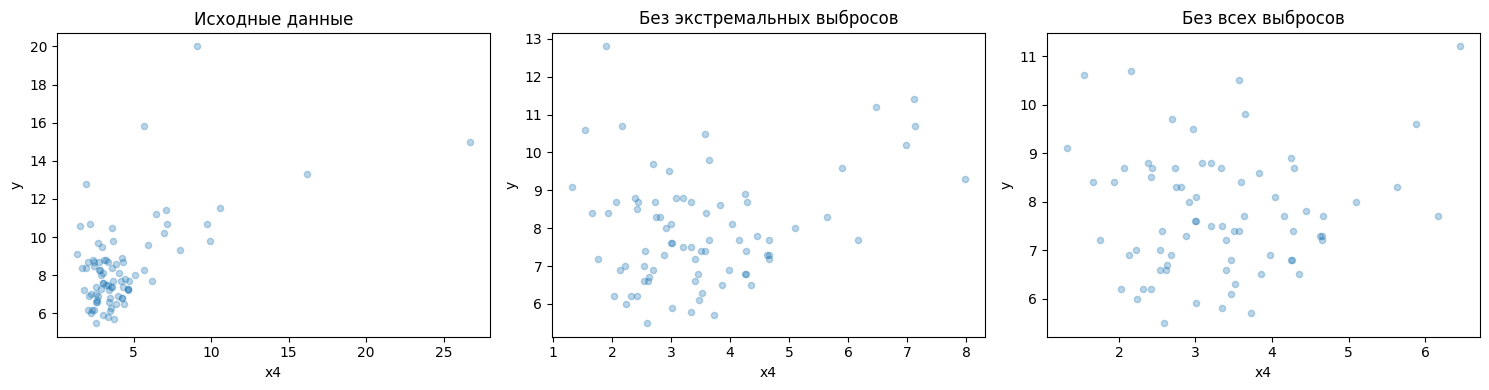

Корреляция для исходных данных: 0.5714469543901732
p_value 1.1188432476029475e-08
Корреляция без экстремальных: 0.25419052162056166
p_value 0.024721362748851772
Корреляция без всех: 0.08711071876727039
p_value 0.4636663853184707
Строим графики scatterplot и рассчитываем коэффициенты корреляции по x5 - Общая площадь жилых помещений, приходящаяся в среднем на одного жителя (кв. м.)


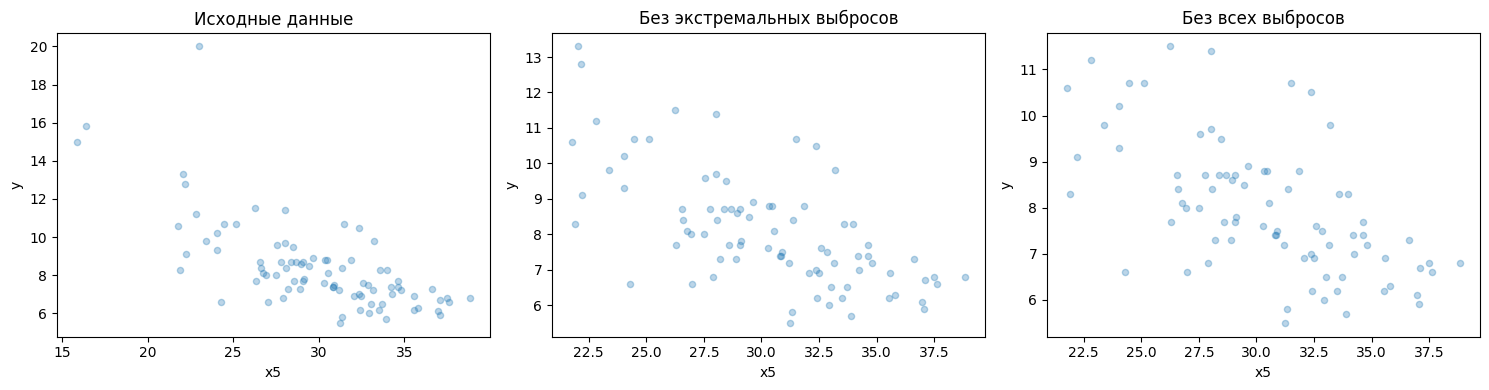

Корреляция для исходных данных: -0.6993552580711166
p_value 9.710180138912714e-14
Корреляция без экстремальных: -0.6570283748505651
p_value 2.0335745641895846e-11
Корреляция без всех: -0.6112478762670575
p_value 1.7225641755433451e-09
CPU times: user 2.83 s, sys: 40.9 ms, total: 2.87 s
Wall time: 2.85 s


In [19]:
%%time
# Строим scatterplot по каждому признаку y, рассчитываем корреляции с учетом и без учета выбросов  и оценим значимость коэффициента корреляции
# Вычисляем границы выбросов
Q1_y = df['y'].quantile(0.25)
Q3_y = df['y'].quantile(0.75)
IQR_y = Q3_y - Q1_y
lower_bound_y = Q1_y - 1.5 * IQR_y
upper_bound_y = Q3_y + 1.5 * IQR_y
lower_bound_critical_y = Q1_y - 3 * IQR_y
upper_bound_critical_y = Q3_y + 3 * IQR_y

for feature in features[:-1]:
    print(f'Строим графики scatterplot и рассчитываем коэффициенты корреляции по {feature} - {features_dict[feature]}')

    # Вычисляем границы выбросов для признака
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    lower_bound_critical = Q1 - 3 * IQR
    upper_bound_critical = Q3 + 3 * IQR

    # Создаём фигуру с тремя осями в одной строке
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Исходные данные
    df.plot(x=feature, y='y', kind='scatter', alpha=0.3, ax=axes[0])
    axes[0].set_title('Исходные данные')

    # 2. Без экстремальных выбросов
    mask_critical = (df['y'] >= lower_bound_critical_y) & (df['y'] <= upper_bound_critical_y) & \
                    (df[feature] >= lower_bound_critical) & (df[feature] <= upper_bound_critical)
    df[mask_critical].plot(x=feature, y='y', kind='scatter', alpha=0.3, ax=axes[1])
    axes[1].set_title('Без экстремальных выбросов')

    # 3. Без умеренных и экстремальных выбросов
    mask_all = (df['y'] >= lower_bound_y) & (df['y'] <= upper_bound_y) & \
               (df[feature] >= lower_bound) & (df[feature] <= upper_bound)
    df[mask_all].plot(x=feature, y='y', kind='scatter', alpha=0.3, ax=axes[2])
    axes[2].set_title('Без всех выбросов')

    plt.tight_layout()
    plt.show()

    # Вычисление корреляций (уберите дублирование)
    print('Корреляция для исходных данных:', df[feature].corr(df['y']))
    r, p_value = stats.pearsonr(df[feature], df['y'])
    print('p_value', p_value)
    print('Корреляция без экстремальных:', df.loc[mask_critical, feature].corr(df.loc[mask_critical, 'y']))
    r, p_value = stats.pearsonr(df.loc[mask_critical, feature], df.loc[mask_critical, 'y'])
    print('p_value', p_value)
    print('Корреляция без всех:', df.loc[mask_all, feature].corr(df.loc[mask_all, 'y']))
    r, p_value = stats.pearsonr(df.loc[mask_all, feature], df.loc[mask_all, 'y'])
    print('p_value', p_value)

Видим, что
- $r_{x1, y}$ = 0,17, 0,22, 0,21 - значения с учетом и без учета выбросов стабильные, величина коэффициента корреляции говорит о наличии слабой прямой линейной связи между коэффициентом рождаемости и среднедушевыми денежными доходами.

- $r_{x2, y}$ = -0,33, -0,19, -0,09 - значения с учетом и без учета выбросов сильно колеблятся, при удалении всех выбросов коэффициент близок к нулю. Величина коэффициента корреляции без учета выбросов говорит об отсутствии линейной связи между коэффициентом рождаемости и долей городского населения в общей численности населения.

- $r_{x3, y}$ = 0,48, 0,17, 0,17 - значения с учетом выбросов значительно выше, чем без учета. Величина коэффициента корреляции 0,17-0,48 говорит о наличии слабой или средней прямой линейной связи между коэффициентом рождаемости и численностью населения с денежными доходами ниже величины прожиточного минимума. Однако $p-value$ > 0.05, что говорит об отсутствии связи.

- $r_{x4, y}$ = 0,57, 0,25, 0,09 - значения с учетом и без учета выбросов сильно колеблятся, при удалении всех выбросов коэффициент близок к нулю. Величина коэффициента корреляции без учета выбросов говорит об отсутствии линейной связи между коэффициентом рождаемости и уровень безработицы.

- $r_{x5, y}$ = -0,7, -0,65, -0,61 - значения с учетом и без учета выбросов стабильные, величина коэффициента корреляции говорит о наличии средней обратной линейной связи между коэффициентом рождаемости и общей площадью жилых помещений, приходящаяся в среднем на одного жителя.

### **Итоговый датасет для моделирования**

Удалим экстремальные выбросы для таргета `y`.

In [20]:
%%time
df = df[df['y'] <= upper_bound_critical_y].reset_index(drop=True)
df.head()

CPU times: user 1.73 ms, sys: 0 ns, total: 1.73 ms
Wall time: 3.82 ms


,region,area,x1,x2,x3,x4,x5,y
0,Белгородская область,ЦФО,56.80,65.40,4.40,3.47,36.98,6.10
1,Брянская область,ЦФО,48.50,69.80,9.10,3.86,33.71,6.50
2,Владимирская область,ЦФО,46.30,77.59,7.40,2.31,33.49,6.20
3,Воронежская область,ЦФО,53.45,68.50,5.40,3.97,35.58,6.90
4,Ивановская область,ЦФО,47.88,82.20,8.00,2.69,32.49,6.90


Визуализируем признаки попарно (на датасете после удаления выбросов) по федеральным округам
CPU times: user 6.06 s, sys: 21.7 ms, total: 6.08 s
Wall time: 6.01 s


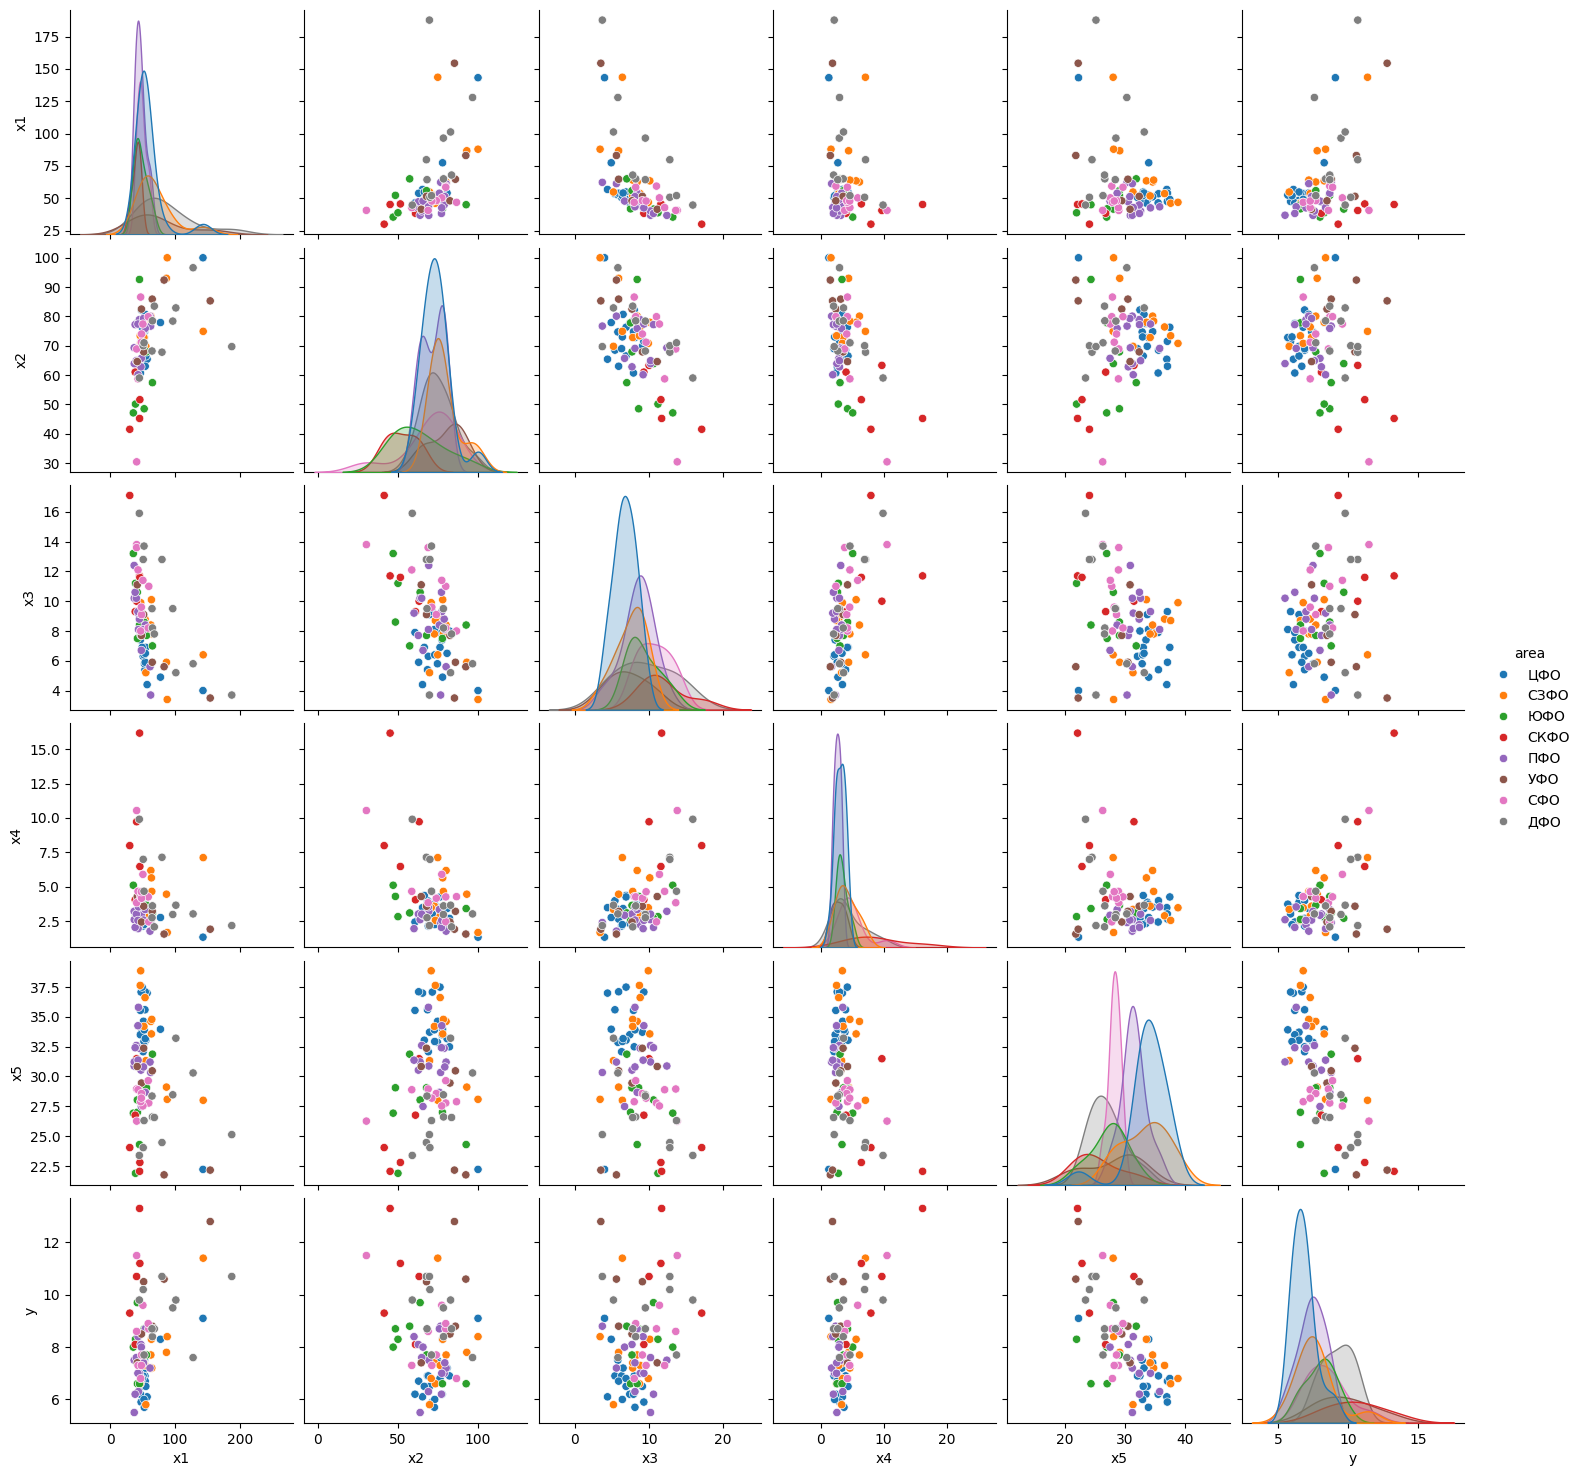

In [21]:
%%time
# Визуализируем признаки попарно по федеральным округам после удаления экстремальных выбросов по y
print('Визуализируем признаки попарно (на датасете после удаления выбросов) по федеральным округам')
sns.pairplot(data=df, hue='area')

In [22]:
# Закодируем федеральные округа дамми
df = pd.get_dummies(df[['area', 'x1', 'x2', 'x3', 'x4', 'x5', 'y']], drop_first=True)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int) # приведем дамми к типу int
df.head()

,x1,x2,x3,x4,x5,y,area_ПФО,area_СЗФО,area_СКФО,area_СФО,area_УФО,area_ЦФО,area_ЮФО
0,56.80,65.40,4.40,3.47,36.98,6.10,0,0,0,0,0,1,0
1,48.50,69.80,9.10,3.86,33.71,6.50,0,0,0,0,0,1,0
2,46.30,77.59,7.40,2.31,33.49,6.20,0,0,0,0,0,1,0
3,53.45,68.50,5.40,3.97,35.58,6.90,0,0,0,0,0,1,0
4,47.88,82.20,8.00,2.69,32.49,6.90,0,0,0,0,0,1,0


In [23]:
%%time
# Разобъем выборку на train и test
df_train, df_test = train_test_split(df, test_size=0.25, random_state=random_state)
# Проверим, что получили разбиение исходных выборок примерно в соотношении 75:25
print(round(df_train.shape[0]/df.shape[0], 3), round(df_test.shape[0]/df.shape[0], 3))

0.744 0.256
CPU times: user 3.51 ms, sys: 0 ns, total: 3.51 ms
Wall time: 3.35 ms


Создадим отдельно датафреймы для признаков и ряды (series) для целевого признака для обучающей и тестовой выборок.

In [24]:
%%time
features_df_train = df_train.drop('y', axis=1) # извлекаем признаки
target_df_train = df_train['y'] # извлекаем целевой признак

features_df_test = df_test.drop('y', axis=1) # извлекаем признаки
target_df_test = df_test['y'] # извлекаем целевой признак

CPU times: user 2.14 ms, sys: 0 ns, total: 2.14 ms
Wall time: 2.74 ms


Целевой признак имеет тип float, т.е. количественный, а значит при моделировании будем решать задачу регрессии, а не классификации.

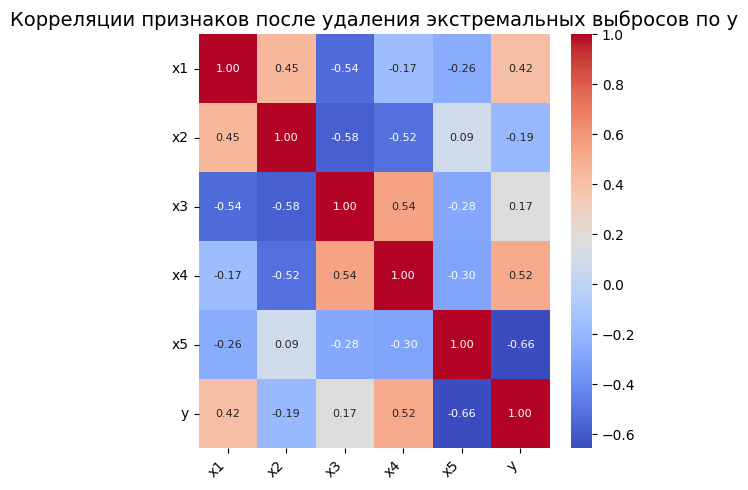

CPU times: user 281 ms, sys: 11 ms, total: 292 ms
Wall time: 290 ms


In [25]:
%%time
# Построим парные корреляции Пирсона между признаками на датасете после удаления экстремальных выбросов по y
plt.figure(figsize=(5, 5))
corr = df[features].corr()
sns.heatmap(
    corr,
    annot=True,              # показываем значения
    fmt='.2f',               # 2 знака после запятой
    cmap='coolwarm',         # цветовая схема
    annot_kws={'size': 8}    # размер шрифта аннотаций
)
plt.title('Корреляции признаков после удаления экстремальных выбросов по y', fontsize=14)
plt.xticks(rotation=45, ha='right')  # поворот подписей по X
plt.yticks(rotation=0)               # подписи по Y горизонтально
plt.tight_layout()
plt.show();

In [26]:
%%time
# Рассчитываем корреляции и оценим значимость коэффициентов корреляции Пирсона
print('Рассчитываем корреляции и оценим значимость коэффициентов корреляции')
r, p_value = stats.pearsonr(df['x1'], df['y'])
print(features_dict['x1'], p_value)
r, p_value = stats.pearsonr(df['x2'], df['y'])
print(features_dict['x2'], p_value)
r, p_value = stats.pearsonr(df['x3'], df['y'])
print(features_dict['x3'], p_value)
r, p_value = stats.pearsonr(df['x4'], df['y'])
print(features_dict['x4'], p_value)
r, p_value = stats.pearsonr(df['x5'], df['y'])
print(features_dict['x5'], p_value)

Рассчитываем корреляции и оценим значимость коэффициентов корреляции
Среднедушевые денежные доходы (в тыс. руб.) 9.836491947441224e-05
Доля городского населения в общей численности населения (%) 0.08711720805587184
Численность населения с денежными доходами ниже величины прожиточного минимума (в % от общей численности населения субъекта) 0.11896452342873025
Уровень безработицы (%) 7.03011587579224e-07
Общая площадь жилых помещений, приходящаяся в среднем на одного жителя (кв. м.) 2.0335745641895846e-11
CPU times: user 3.24 ms, sys: 0 ns, total: 3.24 ms
Wall time: 3.23 ms


In [27]:
%%time
# Построение интервальных оценок для значимых парных коэффициентов корреляции Пирсона
print('Построение интервальных оценок для коэффициента корреляции Пирсона между x1 и y')
res = stats.pearsonr(df['x1'], df['y'])
r = res.statistic
p_value = res.pvalue
print(f"Коэффициент корреляции Пирсона (r) = {r:.4f}")
print(f"p-value = {p_value:.4f}")
# Расчет 95% доверительного интервала
ci = res.confidence_interval(confidence_level=0.95)
print(f"95% Доверительный интервал: [{ci.low:.4f}, {ci.high:.4f}]")

Построение интервальных оценок для коэффициента корреляции Пирсона между x1 и y
Коэффициент корреляции Пирсона (r) = 0.4167
p-value = 0.0001
95% Доверительный интервал: [0.2196, 0.5812]
CPU times: user 1.24 ms, sys: 0 ns, total: 1.24 ms
Wall time: 1.23 ms


### **Проверка `y` на нормальность**

Построим [qqplot](https://www.statsmodels.org/dev/generated/statsmodels.graphics.gofplots.qqplot.html).


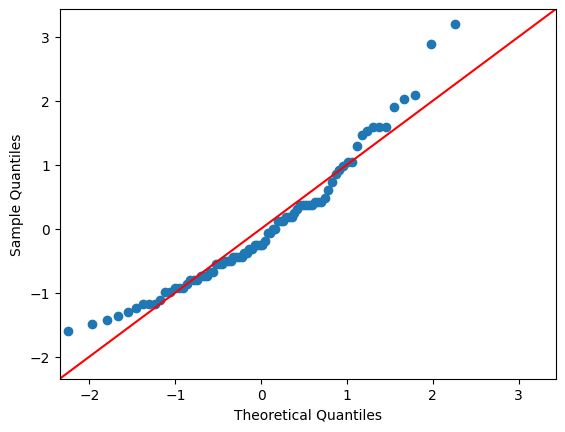

CPU times: user 113 ms, sys: 46 µs, total: 113 ms
Wall time: 113 ms


In [28]:
%%time
fig = sm.qqplot(df['y'], fit=True, line="45")
plt.show()

Воспользуемся статистическим критериями проверки на нормальность из библиотеки [scipy](https://docs.scipy.org/doc/scipy/tutorial/stats.html).

In [29]:
%%time
res = stats.normaltest(df.y)
print('D’Agostino and Pearson’s test')
# print('Statistic', res.statistic)
print('p-value', round(res.pvalue, 3))
res = stats.shapiro(df.y)
print('Shapiro-Wilk test')
# print('Statistic',res.statistic)
print('p-value', round(res.pvalue, 3))
res = stats.kstest(df.y, 'norm')
print('KS-test')
# print('Statistic',res.statistic)
print('p-value', round(res.pvalue, 3))

D’Agostino and Pearson’s test
p-value 0.002
Shapiro-Wilk test
p-value 0.001
KS-test
p-value 0.0
CPU times: user 3.89 ms, sys: 984 µs, total: 4.88 ms
Wall time: 4.69 ms


Нулевая гипотеза в тестах на нормальность заключается в том, что признак имеет нормальное распределение. Поскольку получившееся значение p-value < 0.05, отвергаем нулевую гипотезу о нормальности данных на уровне значимости 5%.

### Вывод по итогам EDA

Предобработка обнаружила три проблемы - нарушения в стиле заголовков, выбросы и разные порядки признаков (x1 и остальных). Исправили заголовки, удалили экстремальные выбросы по `y`, перевели `x1` в тыс. руб., разделив на 1000, закодировали федеральные округа дамми переменными. Дубликатов, некорректных типов данных, пропусков и ошибок нет. Можно перейти к моделированию.

По результатам подготовки данных получили два набора данных:
 - обучающий (features_df_train, target_df_train);
 - тестовый (features_df_test, target_df_test).

## **Линейная регрессия**

Построение линейной регрессионной модели методом пошагового включения:

1. На первом шаге включим в модель независимую переменную `x5`, парная корреляция которой с зависимой переменной максимальна (по модулю).

2. Далее, включим в модель независимую переменную `x4`, парная корреляция которой с зависимой переменной вторая по величине (по модулю). Все коэффициенты модели значимы.

3. Далее, включим в модель независимую переменную `x1`, парная корреляция которой с зависимой переменной третья по величине (по модулю). Все коэффициенты модели значимы.

4. Далее, включим в модель независимую переменную `x2`, парная корреляция которой с зависимой переменной четвертая по величине (по модулю). Все коэффициенты модели значимы.

5. Далее, включим в модель независимую переменную `x3`, парная корреляция которой с зависимой переменной пятая по величине (по модулю). Коэффициент при `x3` не значим на 5-% уровне значимости. Алгоритм прекращается. В регрессию будем включать независимые переменные `x1`, `x2`, `x4`, `x5`.

Несмотря на то, что по итогам корреляционного анализа был сделан вывод об отсутсвии линейной связи между `x2`, `x4` и `y`, оставим эти переменные в модели, так как они повышают качество модели (увеличивают R2).

Добавление дамми по федеральным округам не приводит к росту качества модели.

Обучим модель линейной регрессии на четырех признаках `x1`, `x2`, `x4`, `x5` с помощью пакета sklearn.

In [30]:
%%time
model = LinearRegression() # инициализируем модель LinearRegression
model.fit(features_df_train[['x1', 'x2', 'x4', 'x5']], target_df_train) # обучим модель на тренировочной выборке
# Расчет MSE, RMSE на обучающей выборке
predictions_train = model.predict(features_df_train[['x1', 'x2', 'x4', 'x5']]) # Сделаем предсказания на обучающей выборке
mse_train = mean_squared_error(target_df_train, predictions_train) # рассчитаем MSE модели
rmse_train  = mse_train ** 0.5 # рассчитаем RMSE модели
R2_train = model.score(features_df_train[['x1', 'x2', 'x4', 'x5']], target_df_train)
# Расчет MSE, RMSE на тестовой выборке
predictions_test = model.predict(features_df_test[['x1', 'x2', 'x4', 'x5']]) # получим предсказания модели на валидационной выборке
mse = mean_squared_error(target_df_test, predictions_test) # рассчитаем MSE модели
rmse = mse ** 0.5 # рассчитаем RMSE модели
R2_test = model.score(features_df_test[['x1', 'x2', 'x4', 'x5']], target_df_test)
# Расчет MSE, RMSE на для baseline
predictions = pd.Series(target_df_test.mean(), index= target_df_test.index)
mse_baseline = mean_squared_error(target_df_test, predictions)
rmse_baseline = mse_baseline ** 0.5

# Расчет RMSE
print('RMSE модели на обучающей выборке', round(rmse_train, 2))
print('RMSE модели на тестовой выборке', round(rmse, 2))
print('RMSE baseline на тестовой выборке', round(rmse_baseline, 2))
# Расчет R2
print('R2 на обучающей выборке', round(R2_train, 2))
print('R2 на тестовой выборке', round(R2_test , 2))

RMSE модели на обучающей выборке 0.95
RMSE модели на тестовой выборке 0.88
RMSE baseline на тестовой выборке 1.45
R2 на обучающей выборке 0.68
R2 на тестовой выборке 0.63
CPU times: user 15.8 ms, sys: 972 µs, total: 16.7 ms
Wall time: 16.6 ms


RMSE и R2 на тесте не значительно упали по сравнению с обучающей выборкой, значит нет переобучения.

RMSE построенной модели значительно ниже RMSE baseline, следовательно построенная модель лучше, чем baseline.

In [31]:
%%time
print('Коэффициенты модели', model.coef_)
print('Свобоный член', model.intercept_)

Коэффициенты модели [ 0.0269183  -0.03615254  0.25495913 -0.14976843]
Свобоный член 12.678103522053206
CPU times: user 1.32 ms, sys: 0 ns, total: 1.32 ms
Wall time: 1.19 ms


Для получения большего числа статистик построенной регрессии, воспользуемся statsmodels.api (sm).

In [32]:
%%time
X = features_df_train[['x1', 'x2', 'x4', 'x5']]
y = target_df_train
Xc = sm.add_constant(X) # Добавим константу
# Реализуйте регрессию с помощью sm.OLS
model = sm.OLS(y,Xc)
results = model.fit()
# Выведем summary построенной модели
results.summary()

CPU times: user 9.02 ms, sys: 1 ms, total: 10 ms
Wall time: 9.65 ms


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     29.71
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           2.86e-13
Time:                        08:44:36   Log-Likelihood:                -83.263
No. Observations:                  61   AIC:                             176.5
Df Residuals:                      56   BIC:                             187.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.6781      1.512      8.383      0.000       9.648      15.708
x1             0.0269      0.005      5.099      0.000       0.016       0.037
x2            -0.0362      0.013     -2.797      0.007      -0.062      -0.010
x4             0.2550      0.064      3.992      0.000       0.127       0.383
x5            -0.1498      0.033     -4.553      0.000      -0.216      -0.084
==============================================================================
Omnibus:                        1.561   Durbin-Watson:                   2.297
Prob(Omnibus):                  0.458   Jarque-Bera (JB):                1.207
Skew:                           0.345   Prob(JB):                        0.547
Kurtosis:                       3.009   Cond. No.                     1.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Проверим нормальность распределения остатков.

D’Agostino and Pearson’s test
p-value 0.458
Shapiro-Wilk test
p-value 0.518
KS-test
p-value 0.897


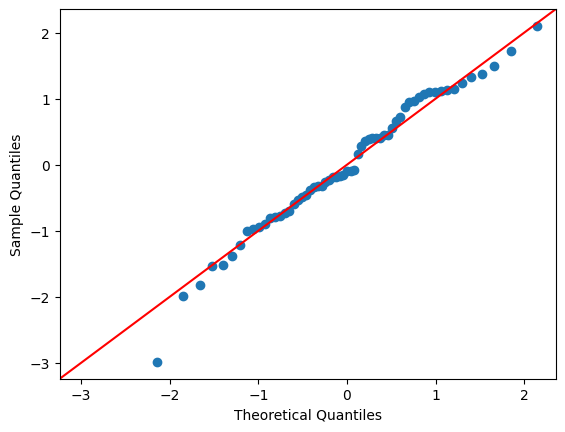

In [45]:
# Обучающая выборка
sm.qqplot(predictions_train-target_df_train, fit=True, line="45")
res = stats.normaltest(predictions_train-target_df_train)
print('D’Agostino and Pearson’s test')
# print('Statistic', res.statistic)
print('p-value', round(res.pvalue, 3))
res = stats.shapiro(predictions_train-target_df_train)
print('Shapiro-Wilk test')
# print('Statistic',res.statistic)
print('p-value', round(res.pvalue, 3))
res = stats.kstest(predictions_train-target_df_train, 'norm')
print('KS-test')
# print('Statistic',res.statistic)
print('p-value', round(res.pvalue, 3))


D’Agostino and Pearson’s test
p-value 0.803
Shapiro-Wilk test
p-value 0.989
KS-test
p-value 0.48


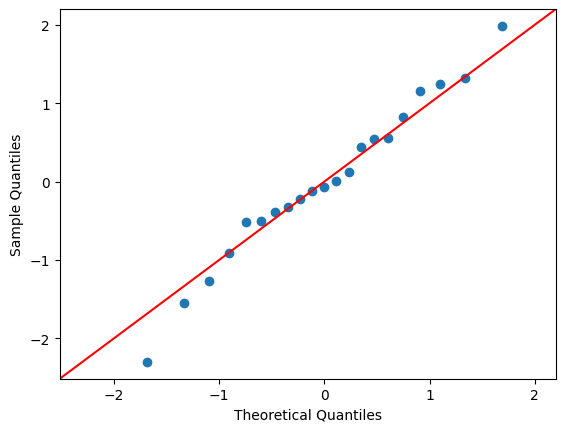

In [46]:
# Тестовая выборка
sm.qqplot(predictions_test-target_df_test, fit=True, line="45")
res = stats.normaltest(predictions_test-target_df_test)
print('D’Agostino and Pearson’s test')
# print('Statistic', res.statistic)
print('p-value', round(res.pvalue, 3))
res = stats.shapiro(predictions_test-target_df_test)
print('Shapiro-Wilk test')
# print('Statistic',res.statistic)
print('p-value', round(res.pvalue, 3))
res = stats.kstest(predictions_test-target_df_test, 'norm')
print('KS-test')
# print('Statistic',res.statistic)
print('p-value', round(res.pvalue, 3))

Поскольку получившееся значение p-value > 0.05, не отвергаем нулевую гипотезу о нормальности остатков на уровне значимости 5%.

Уравнение регрессии значимо при α=0,05, т.к. Prob (F-statistic) < 0,05.  Значимы все коэффициенты регрессии.

Из уравнения регрессии следует, что при увеличении среднедушевых денежных доходов (x1) на на 1 тыс. руб., коэффициент рождаемости увеличится на 0,0269 промилле. При увеличение доли городского населения в регионе (х2) на 1%,  коэффициент рождаемости снижается на 0,0362 промилле. Увеличение уровня безработицы (x4) на 1% ведет к росту уровня рождаемости на 0.255 промилле. А рост общей площади жилья (x5) в среднем на одного человека приводит к снижению коэффициента рождаемости на 0,1498 промилле.

Коэффициент детерминации R2=0,63 на тестовой выборке показывает долю вариации таргета (коэффициент рождаемости y)  под воздействием включенных в модель факторов (x1, x2, x4, x5). Следовательно, около 63% вариации зависимой переменной y учтено в модели и обусловлено влиянием включенных факторов. Остальная часть вариации обусловлена действием неуточненных факторов (х3, а также другими экономическими, социальными и др. факторами).

## **Итоговый вывод**

**Рабочие гипотезы**: **H1** коэффициент рождаемости `y` имеет нормальный закон распределения; **H2** отсутствует линейная корреляционная зависимость между уровнем рождаемости и среднедушевыми доходами населения; **H3** отсутствует линейная корреляционная зависимость между удельным весом городского населения в общей численности населения и коэффициентом рождаемости; **H4** отсутствует линейная корреляционная зависимость между численностью населения с денежными доходами ниже величины прожиточного минимума и коэффициентом рождаемости; **H5** отсутствует линейная корреляционная зависимость между уровнем безработицы и коэффициентом рождаемости; **H6** отсутствует линейная корреляционная зависимость между общей площадью жилых помещений, приходящаяся в среднем на одного жителя и коэффициентом рождаемости.

В ходе работы были отвергнуты следующие из рабочих гипотез:H1, H2, H6.  

При построении регрессионной модели  были получены следующие выводы:

-при увеличении среднедушевых денежных доходов, коэффициент рождаемости увеличивается. 95 процентный доверительный интервал для линейного коэффициента корреляции между среднедушевыми денежными доходами и рождаемостью составляет [0.2196, 0.5812].

-при увеличение доли городского населения в регионе, коэффициент рождаемости снижается, что возможно связано с измененеизменением репродуктивного поведения в городах;

-увеличение уровня безработицы ведет к росту уровня рождаемости, что можно объяснить тем, что не работающие посвящают себя рождению и воспитанию детей;

-рост общей площади жилья в среднем на одного человека приводит к снижению коэффициента рождаемости. Такую закономерность можно обосновать тем, что сравнительно низкая обеспеченность жильем может быть характерна для регионов с традиционно большим количеством детей в семье.